<a href="https://colab.research.google.com/github/Naangeal01/Problema-Protot-pico-5to-sem/blob/main/Problema-Protot-pico-5to-sem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/tmp/ipykernel_9342/2572277692.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/2572277692.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/2572277692.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/2572277692.py:26: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To 

--- PREDICCIONES PARA MAYO 2026 ---

Analizando: Pechuga
  Min: $84.50
  Max: $87.79
  Frec: $86.74


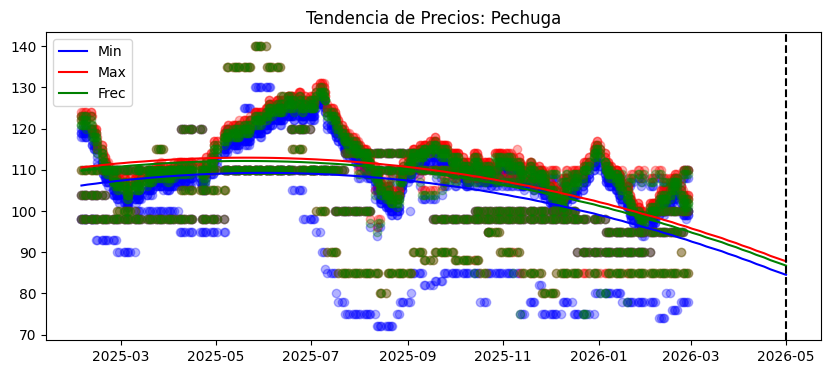


Analizando: Pierna/muslo
  Min: $36.94
  Max: $39.64
  Frec: $38.74


/tmp/ipykernel_9342/2572277692.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],
/tmp/ipykernel_9342/2572277692.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],
/tmp/ipykernel_9342/2572277692.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],


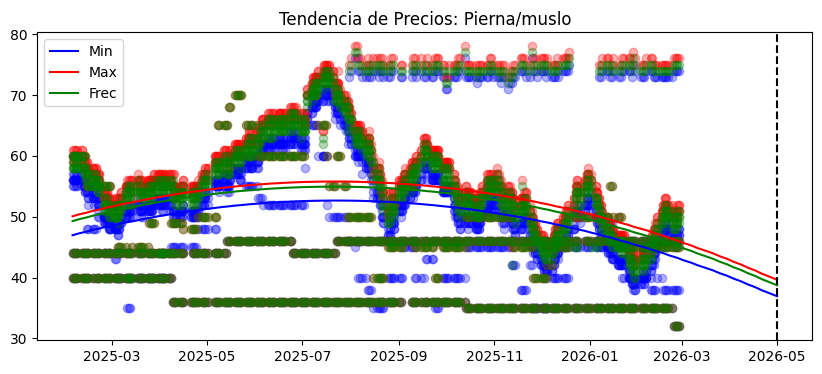


Analizando: Retazo
  Min: $25.23
  Max: $27.44
  Frec: $26.50


/tmp/ipykernel_9342/2572277692.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],
/tmp/ipykernel_9342/2572277692.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],
/tmp/ipykernel_9342/2572277692.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],


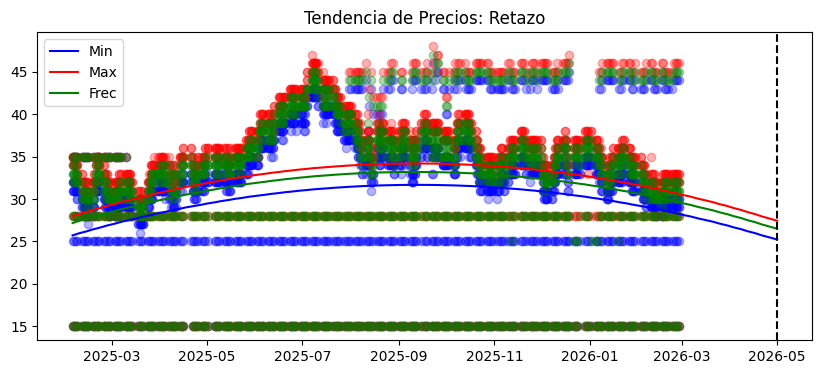


Analizando: Vísceras
  Min: $22.03
  Max: $22.97
  Frec: $22.11


/tmp/ipykernel_9342/2572277692.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],
/tmp/ipykernel_9342/2572277692.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],
/tmp/ipykernel_9342/2572277692.py:87: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],


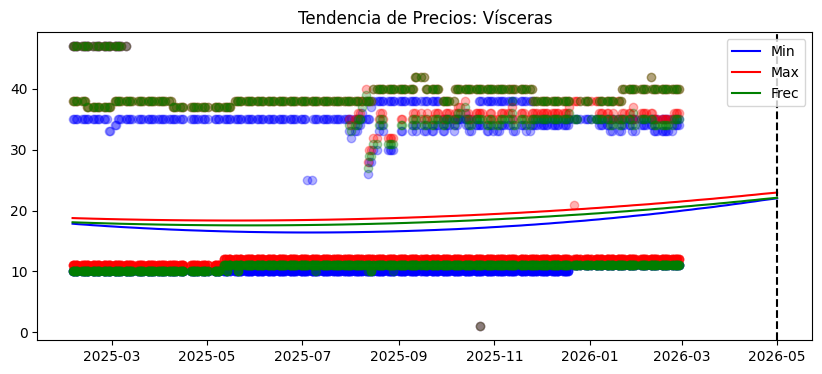

In [ ]:
 import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from datetime import datetime

path = '/content/base de datos.xlsx'

# 1. Función para cargar y limpiar con nombres de columnas planos
def cargar_datos_limpios(ruta):
    try:
        # Leemos el Excel; header=[1,2] es por tu estructura de Pechuga -> Min/Max/Frec
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []

        for nombre, df in dict_hojas.items():
            # Reparar las columnas para que no sean un lío de tuplas
            # Esto convierte ('Pechuga', 'Min') en algo procesable
            df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in col[1] else col[0] for col in df.columns]

            # La primera columna SIEMPRE será nuestra Fecha, sin importar el nombre
            df = df.rename(columns={df.columns[0]: 'Fecha'})

            # Convertir fecha y limpiar nulos
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            df = df.dropna(subset=['Fecha'])
            lista_df.append(df)

        return pd.concat(lista_df, ignore_index=True)
    except Exception as e:
        print(f"Error al abrir el Excel: {e}")
        return None

# 2. Limpieza de símbolos de dinero
def limpiar_dinero(valor):
    if pd.isna(valor) or str(valor).strip() in ['-', 'nan', '']:
        return np.nan
    try:
        return float(str(valor).replace('$', '').replace(',', '').strip())
    except:
        return np.nan

# 3. Procesamiento y Predicción
df_base = cargar_datos_limpios(path)

if df_base is not None:
    # Identificamos las piezas (Pechuga, Pierna/muslo, etc.)
    # Buscamos las columnas que terminan en _Min para saber qué piezas hay
    piezas = [c.replace('_Min', '') for c in df_base.columns if '_Min' in c]

    fecha_proyectada = datetime(2026, 5, 1)
    ord_proyectada = fecha_proyectada.toordinal()

    print(f"--- PREDICCIONES PARA MAYO 2026 ---")

    for pieza in piezas:
        try:
            # Creamos un dataframe temporal para esta pieza
            # Buscamos variaciones de 'Frec' o 'Frecc'
            col_frec = [c for c in df_base.columns if pieza in c and 'Fre' in c][0]

            df_p = pd.DataFrame({
                'Fecha': df_base['Fecha'],
                'Min': df_base[f'{pieza}_Min'].apply(limpiar_dinero),
                'Max': df_base[f'{pieza}_Max'].apply(limpiar_dinero),
                'Frec': df_base[col_frec].apply(limpiar_dinero)
            }).dropna()

            if len(df_p) < 3: continue

            X = df_p['Fecha'].map(datetime.toordinal).values.reshape(-1, 1)
            poly = PolynomialFeatures(degree=2)
            X_poly = poly.fit_transform(X)

            plt.figure(figsize=(10, 4))
            print(f"\nAnalizando: {pieza}")

            for col, color in zip(['Min', 'Max', 'Frec'], ['blue', 'red', 'green']):
                modelo = LinearRegression().fit(X_poly, df_p[col])
                pred = modelo.predict(poly.transform([[ord_proyectada]]))[0]
                print(f"  {col}: ${pred:,.2f}")

                # Gráfica
                plt.scatter(df_p['Fecha'], df_p[col], color=color, alpha=0.3)
                fechas_continuas = np.linspace(X.min(), ord_proyectada, 100).reshape(-1, 1)
                plt.plot([datetime.fromordinal(int(d)) for d in fechas_continuas],
                         modelo.predict(poly.transform(fechas_continuas)), color=color, label=col)

            plt.title(f"Tendencia de Precios: {pieza}")
            plt.axvline(fecha_proyectada, color='black', linestyle='--')
            plt.legend()
            plt.show()

        except Exception as e:
            print(f"Error en pieza {pieza}: {e}")

/tmp/ipykernel_9342/784409687.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/784409687.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/784409687.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/784409687.py:17: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensu

--- PREDICCIONES CON ÁRBOL DE DECISIÓN (MAYO 2026) ---

Analizando: Pechuga
  Min: $97.71
  Max: $101.00


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


  Frec: $100.15


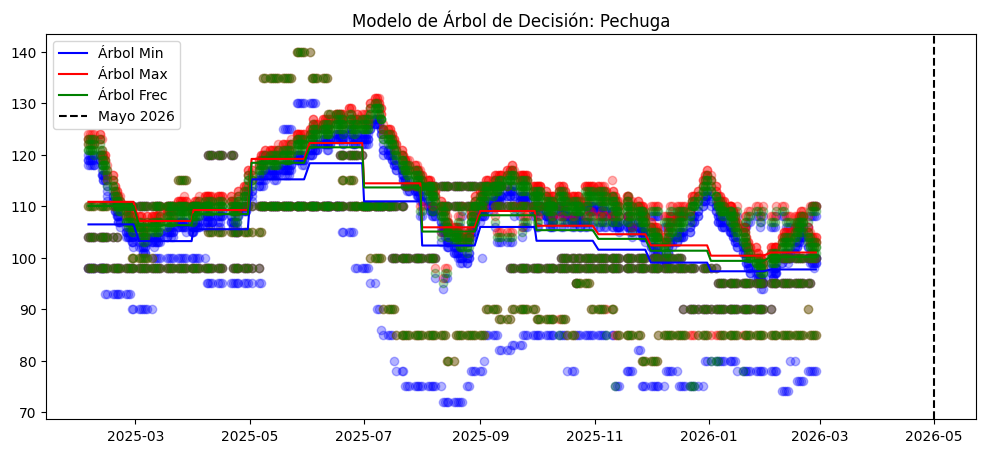

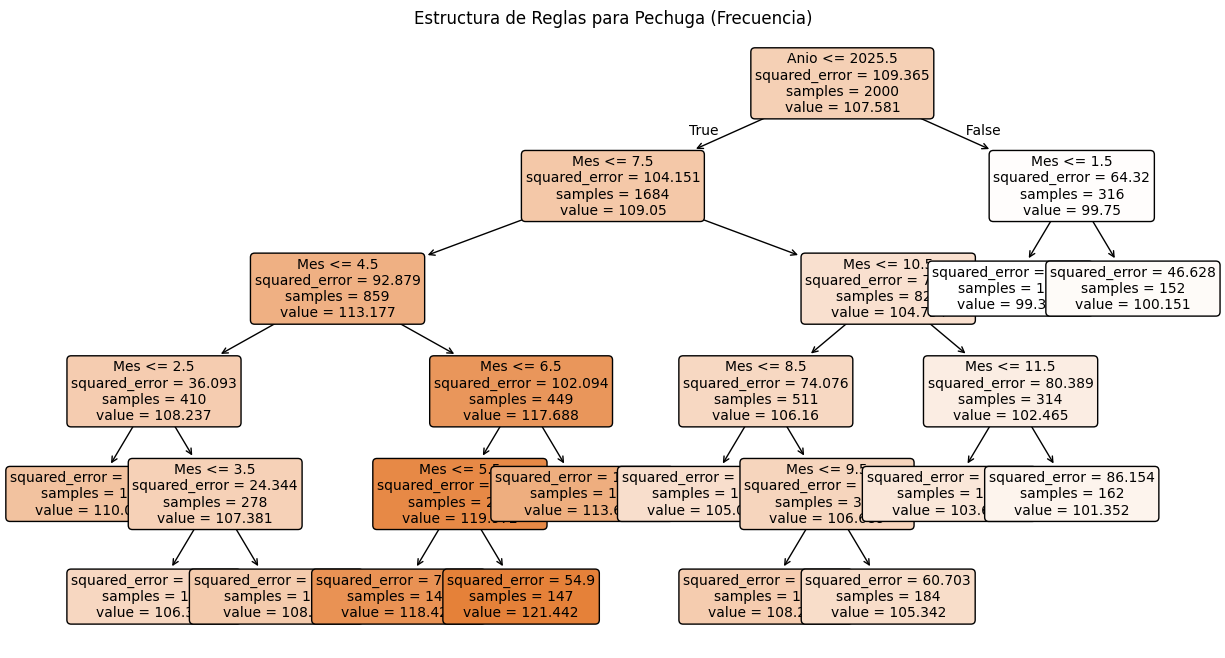


Analizando: Pierna/muslo
  Min: $51.99
  Max: $55.47
  Frec: $54.65


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


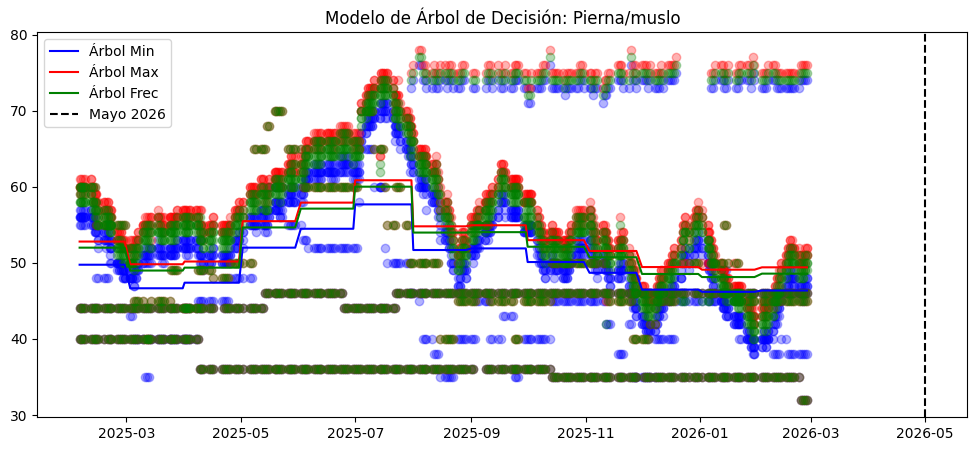

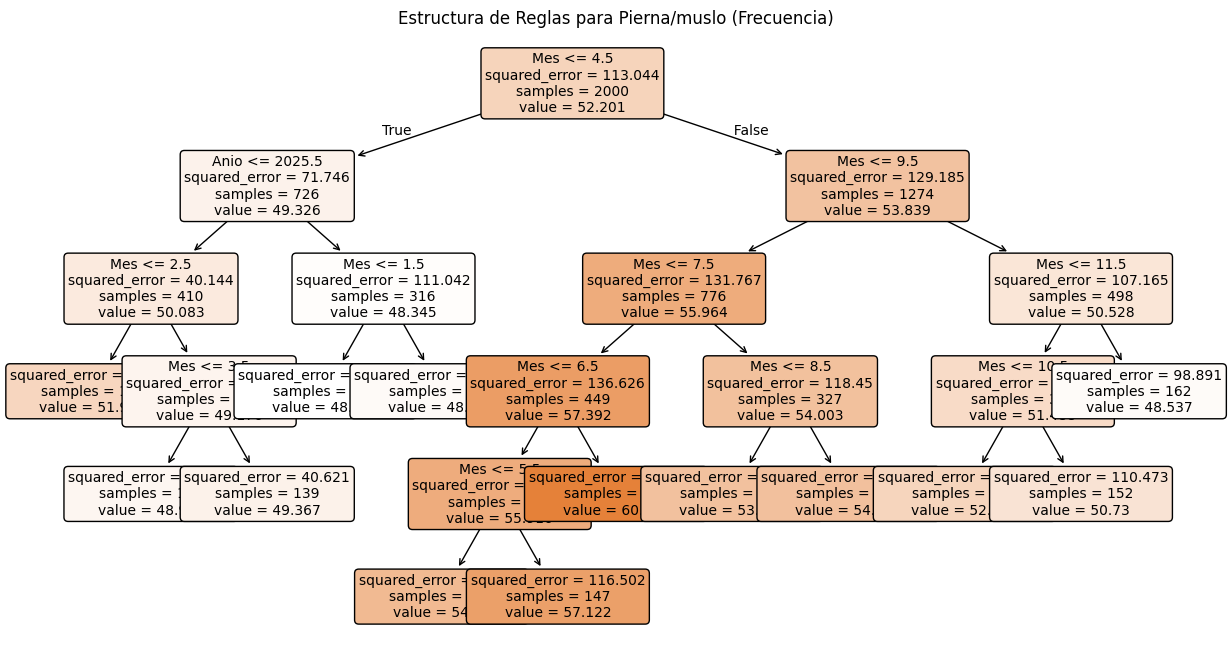


Analizando: Retazo
  Min: $28.81
  Max: $31.26
  Frec: $30.26


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


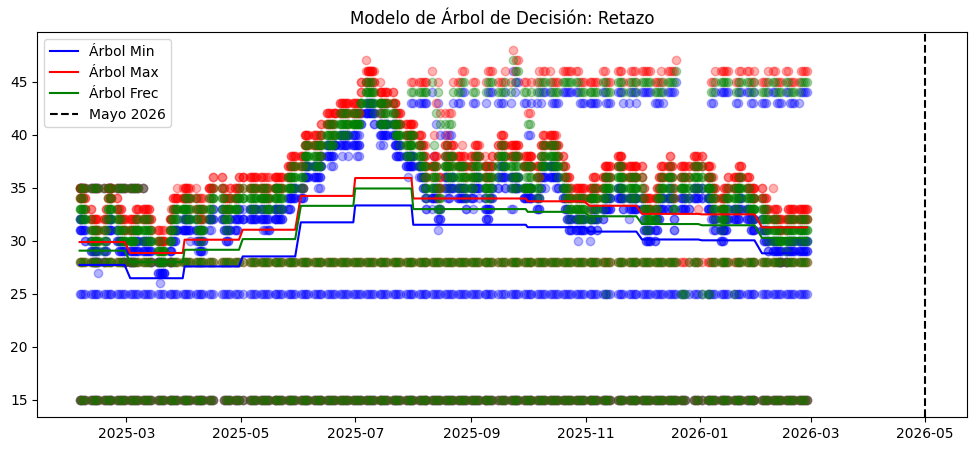

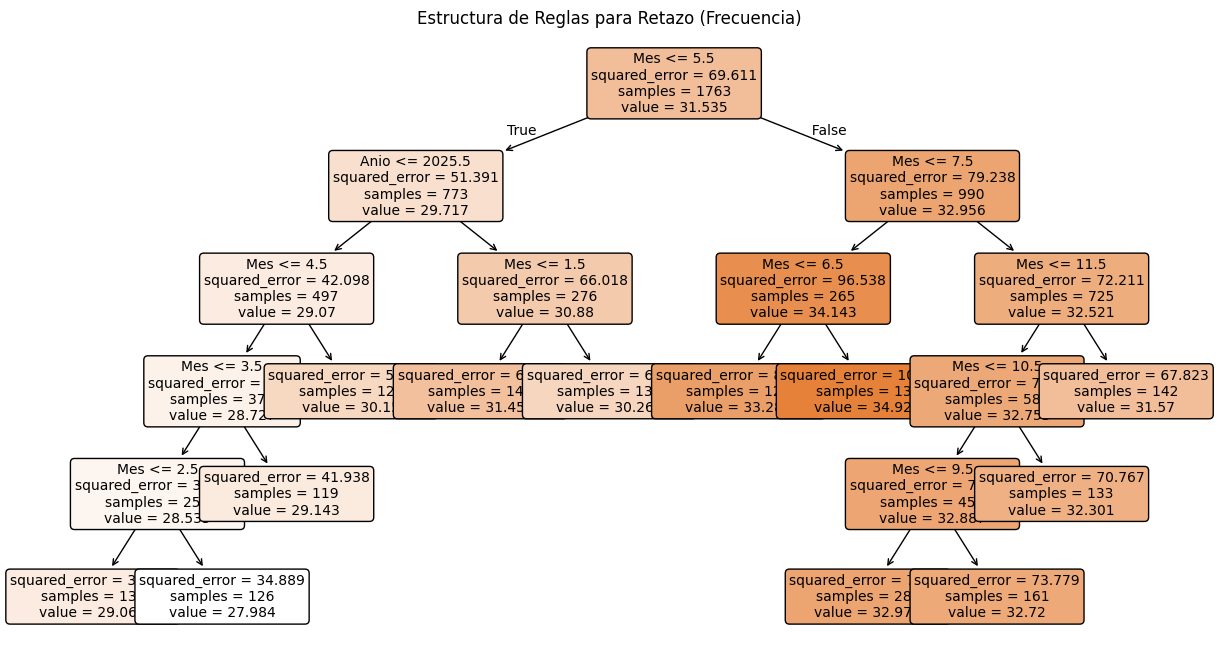


Analizando: Vísceras
  Min: $15.04
  Max: $16.82
  Frec: $16.02


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


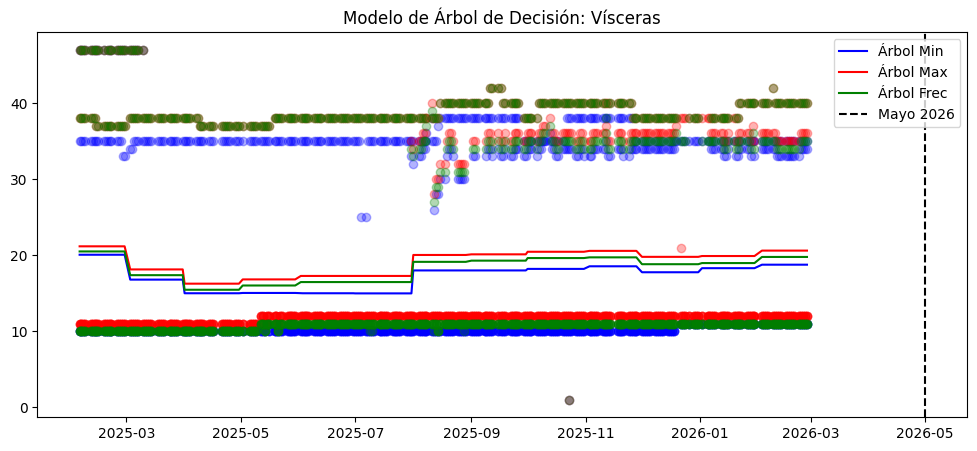

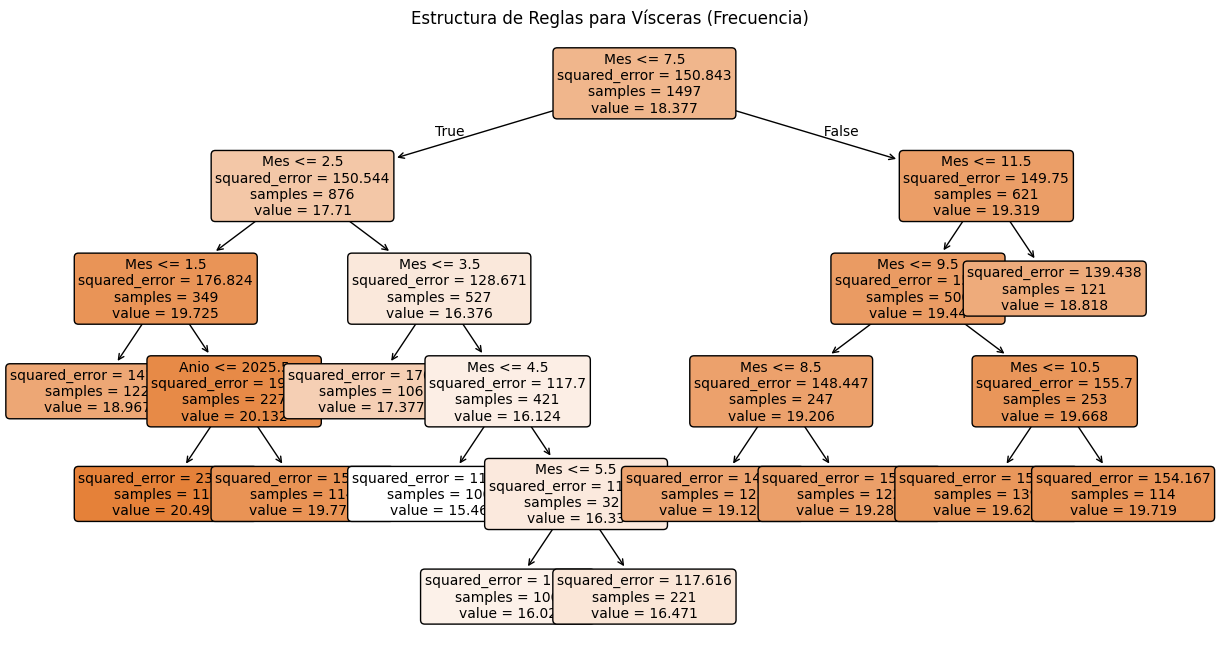

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree # Cambiamos regresión por Árbol
from datetime import datetime

path = 'base de datos.xlsx' # Asegúrate de que el archivo esté en la misma carpeta

# 1. Tu función de carga (se mantiene igual)
def cargar_datos_limpios(ruta):
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []
        for nombre, df in dict_hojas.items():
            df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in col[1] else col[0] for col in df.columns]
            df = df.rename(columns={df.columns[0]: 'Fecha'})
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            df = df.dropna(subset=['Fecha'])
            lista_df.append(df)
        return pd.concat(lista_df, ignore_index=True)
    except Exception as e:
        print(f"Error al abrir el Excel: {e}")
        return None

# 2. Función de limpieza de dinero (se mantiene igual)
def limpiar_dinero(valor):
    if pd.isna(valor) or str(valor).strip() in ['-', 'nan', '']:
        return np.nan
    try:
        return float(str(valor).replace('$', '').replace(',', '').strip())
    except:
        return np.nan

# --- PROCESAMIENTO CON ÁRBOL DE DECISIÓN ---
df_base = cargar_datos_limpios(path)

if df_base is not None:
    piezas = [c.replace('_Min', '') for c in df_base.columns if '_Min' in c]

    # Fecha a predecir: Mayo 2026
    fecha_proyectada = datetime(2026, 5, 1)

    # Para los árboles, es mejor usar características como Año y Mes por separado
    X_proyectada = [[fecha_proyectada.year, fecha_proyectada.month]]

    print(f"--- PREDICCIONES CON ÁRBOL DE DECISIÓN (MAYO 2026) ---")

    for pieza in piezas:
        try:
            col_frec = [c for c in df_base.columns if pieza in c and 'Fre' in c][0]

            df_p = pd.DataFrame({
                'Fecha': df_base['Fecha'],
                'Min': df_base[f'{pieza}_Min'].apply(limpiar_dinero),
                'Max': df_base[f'{pieza}_Max'].apply(limpiar_dinero),
                'Frec': df_base[col_frec].apply(limpiar_dinero)
            }).dropna()

            if len(df_p) < 3: continue

            # PREPARACIÓN DE CARACTERÍSTICAS (Features)
            # Los árboles funcionan mejor con componentes de fecha separados
            X = pd.DataFrame({
                'Anio': df_p['Fecha'].dt.year,
                'Mes': df_p['Fecha'].dt.month
            })

            print(f"\nAnalizando: {pieza}")
            plt.figure(figsize=(12, 5))

            for col, color in zip(['Min', 'Max', 'Frec'], ['blue', 'red', 'green']):
                # CREAR Y ENTRENAR EL ÁRBOL
                # max_depth evita que el árbol se vuelva "loco" con datos muy específicos
                modelo_arbol = DecisionTreeRegressor(max_depth=5, random_state=42)
                modelo_arbol.fit(X, df_p[col])

                # Predicción
                pred = modelo_arbol.predict(X_proyectada)[0]
                print(f"  {col}: ${pred:,.2f}")

                # Gráfica de la serie temporal
                plt.scatter(df_p['Fecha'], df_p[col], color=color, alpha=0.3)

                # Para visualizar la "escalera" del árbol en el tiempo
                df_p = df_p.sort_values('Fecha')
                plt.plot(df_p['Fecha'], modelo_arbol.predict(X), color=color, label=f"Árbol {col}")

            plt.title(f"Modelo de Árbol de Decisión: {pieza}")
            plt.axvline(fecha_proyectada, color='black', linestyle='--', label='Mayo 2026')
            plt.legend()
            plt.show()

            # OPCIONAL: Visualizar la estructura del último árbol (Frecuencia)
            plt.figure(figsize=(15, 8))
            plot_tree(modelo_arbol, feature_names=['Anio', 'Mes'], filled=True, rounded=True, fontsize=10)
            plt.title(f"Estructura de Reglas para {pieza} (Frecuencia)")
            plt.show()

        except Exception as e:
            print(f"Error en pieza {pieza}: {e}")

In [ ]:
import pandas as pd
import numpy as np

def calcular_nodo_regresion(y_total, y_izq, y_der):
    """
    Calcula todos los componentes de un nodo en un árbol de decisión de regresión.
    """
    # 1. RSS Antes de dividir
    promedio_total = np.mean(y_total)
    rss_antes = np.sum((y_total - promedio_total)**2)

    # 2. Cálculos Nodo Izquierdo
    promedio_izq = np.mean(y_izq)
    rss_izq = np.sum((y_izq - promedio_izq)**2)

    # 3. Cálculos Nodo Derecho
    promedio_der = np.mean(y_der)
    rss_der = np.sum((y_der - promedio_der)**2)

    # 4. RSS Total después de dividir
    rss_despues = rss_izq + rss_der

    # 5. Reducción del error
    reduccion = rss_antes - rss_despues

    # Mostrar resultados formateados
    print(f"{'--- CÁLCULO DE ÁRBOL DE DECISIÓN (REGRESIÓN) ---':^50}")
    print(f"{'Métrica':<30} | {'Valor':<15}")
    print("-" * 50)
    print(f"{'RSS Inicial':<30} | {rss_antes:15.4f}")
    print(f"{'Promedio Nodo Izquierdo':<30} | {promedio_izq:15.4f}")
    print(f"{'RSS Nodo Izquierdo':<30} | {rss_izq:15.4f}")
    print(f"{'Promedio Nodo Derecho':<30} | {promedio_der:15.4f}")
    print(f"{'RSS Nodo Derecho':<30} | {rss_der:15.4f}")
    print(f"{'RSS Total Post-División':<30} | {rss_despues:15.4f}")
    print("-" * 50)
    print(f"{'REDUCCIÓN TOTAL DEL ERROR':<30} | {reduccion:15.4f}")

# --- PREPARACIÓN DE DATOS DESDE TU ARCHIVO ---
# Cargamos el archivo que identificamos con los datos de Pechuga
df = pd.read_excel('base de datos.xlsx', header=1)
precios_raw = df['Precios'].iloc[4:].dropna()
y = precios_raw.replace('[$,]', '', regex=True).astype(float).values

# Definimos el punto de corte (ejemplo: a la mitad de los datos)
punto_corte = len(y) // 2
nodo_izquierdo = y[:punto_corte]
nodo_derecho = y[punto_corte:]

# Ejecutar la función
calcular_nodo_regresion(y, nodo_izquierdo, nodo_derecho)

 --- CÁLCULO DE ÁRBOL DE DECISIÓN (REGRESIÓN) --- 
Métrica                        | Valor          
--------------------------------------------------
RSS Inicial                    |       9150.2308
Promedio Nodo Izquierdo        |        111.2692
RSS Nodo Izquierdo             |       1369.3462
Promedio Nodo Derecho          |        104.3462
RSS Nodo Derecho               |       5911.6538
RSS Total Post-División        |       7281.0000
--------------------------------------------------
REDUCCIÓN TOTAL DEL ERROR      |       1869.2308


/tmp/ipykernel_9342/3223451116.py:43: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = precios_raw.replace('[$,]', '', regex=True).astype(float).values


In [ ]:
import numpy as np

# --- 1. DATOS DE ENTRADA (Precios de Pechuga extraídos) ---
# y contiene los precios que limpiamos de la base de datos
y = np.array([100.0, 100.0, 105.0, 98.0, 95.0, 110.0]) # Ejemplo simplificado

# --- 2. CÁLCULO GENERAL (RSS ANTES DE DIVIDIR) ---
promedio_total = np.mean(y)
rss_antes = np.sum((y - promedio_total)**2)

# --- 3. FORMACIÓN DE NODOS (Punto de corte) ---
punto_corte = 3
nodo_izquierdo = y[:punto_corte]
nodo_derecho = y[punto_corte:]

# --- 4. CÁLCULOS NODO IZQUIERDO ---
promedio_izq = np.mean(nodo_izquierdo)
rss_izq = np.sum((nodo_izquierdo - promedio_izq)**2)

# --- 5. CÁLCULOS NODO DERECHO ---
promedio_der = np.mean(nodo_derecho)
rss_der = np.sum((nodo_derecho - promedio_der)**2)

# --- 6. RESULTADOS FINALES ---
rss_total_despues = rss_izq + rss_der
reduccion_error = rss_antes - rss_total_despues

# --- SALIDA LIMPIA Y SIN AMONTONAR ---
print(f"1. RSS Inicial: {rss_antes:.4f}")
print("-" * 30)
print(f"2. Nodo Izquierdo:")
print(f"   - Promedio: {promedio_izq:.4f}")
print(f"   - RSS: {rss_izq:.4f}")
print("-" * 30)
print(f"3. Nodo Derecho:")
print(f"   - Promedio: {promedio_der:.4f}")
print(f"   - RSS: {rss_der:.4f}")
print("-" * 30)
print(f"4. RSS Total Post-División: {rss_total_despues:.4f}")
print(f"5. Reducción del Error: {reduccion_error:.4f}")

1. RSS Inicial: 143.3333
------------------------------
2. Nodo Izquierdo:
   - Promedio: 101.6667
   - RSS: 16.6667
------------------------------
3. Nodo Derecho:
   - Promedio: 101.0000
   - RSS: 126.0000
------------------------------
4. RSS Total Post-División: 142.6667
5. Reducción del Error: 0.6667


/tmp/ipykernel_9342/2193139343.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/2193139343.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/2193139343.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/2193139343.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To 

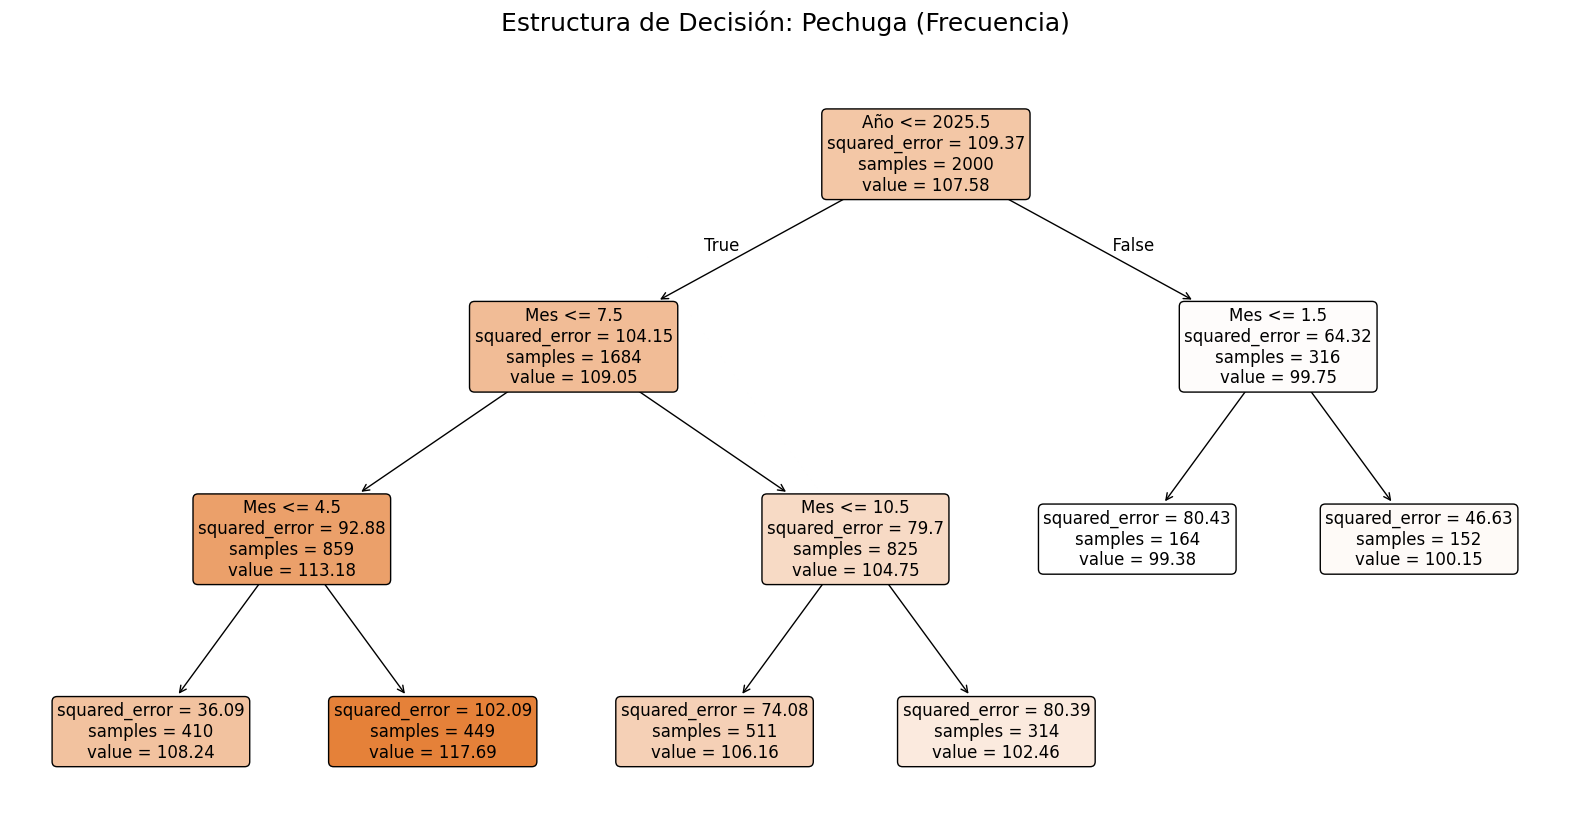


 Predicción estimada para Mayo 2026: $100.15


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from datetime import datetime

# --- CONFIGURACIÓN ---
path = '/content/base de datos.xlsx'
PIEZA_OBJETIVO = 'Pechuga'

def cargar_datos_limpios(ruta):
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []
        for nombre, df in dict_hojas.items():
            df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in str(col[1]) else col[0] for col in df.columns]
            df = df.rename(columns={df.columns[0]: 'Fecha'})
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            df = df.dropna(subset=['Fecha'])
            lista_df.append(df)
        return pd.concat(lista_df, ignore_index=True)
    except Exception as e:
        print(f" Error: {e}")
        return None

def limpiar_dinero(valor):
    if pd.isna(valor) or str(valor).strip() in ['-', 'nan', '']:
        return np.nan
    try:
        return float(str(valor).replace('$', '').replace(',', '').strip())
    except:
        return np.nan

df_base = cargar_datos_limpios(path)

if df_base is not None:
    try:
        # Identificar columna de frecuencia
        col_frec = [c for c in df_base.columns if PIEZA_OBJETIVO in c and 'Fre' in c][0]

        df_p = pd.DataFrame({
            'Fecha': df_base['Fecha'],
            'Min': df_base[f'{PIEZA_OBJETIVO}_Min'].apply(limpiar_dinero),
            'Max': df_base[f'{PIEZA_OBJETIVO}_Max'].apply(limpiar_dinero),
            'Frec': df_base[col_frec].apply(limpiar_dinero)
        }).dropna()

        # Variables: Año y Mes
        X = pd.DataFrame({
            'Año': df_p['Fecha'].dt.year,
            'Mes': df_p['Fecha'].dt.month
        })

        # Modelo (Limitado a profundidad 3 para que NO se amontone)
        # Esto genera un árbol de máximo 8 nodos finales, muy fácil de leer.
        modelo_legible = DecisionTreeRegressor(max_depth=3, random_state=42)
        modelo_legible.fit(X, df_p['Frec'])

        # --- DIBUJO DEL ÁRBOL (VERSION ESPACIADA) ---
        plt.figure(figsize=(20, 10)) # Lienzo extra grande

        plot_tree(modelo_legible,
                  feature_names=['Año', 'Mes'],
                  filled=True,
                  rounded=True,
                  precision=2,
                  fontsize=12, # Letra grande
                  proportion=False) # Muestra valores reales, no proporciones

        plt.title(f"Estructura de Decisión: {PIEZA_OBJETIVO} (Frecuencia)", fontsize=18, pad=20)
        plt.show()

        # Predicción rápida para verificar
        fecha_proyectada = datetime(2026, 5, 1)
        pred = modelo_legible.predict([[fecha_proyectada.year, fecha_proyectada.month]])[0]
        print(f"\n Predicción estimada para Mayo 2026: ${pred:,.2f}")

    except Exception as e:
        print(f"|Error al generar el árbol: {e}")

/tmp/ipykernel_9342/276302708.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/276302708.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/276302708.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/276302708.py:20: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensu

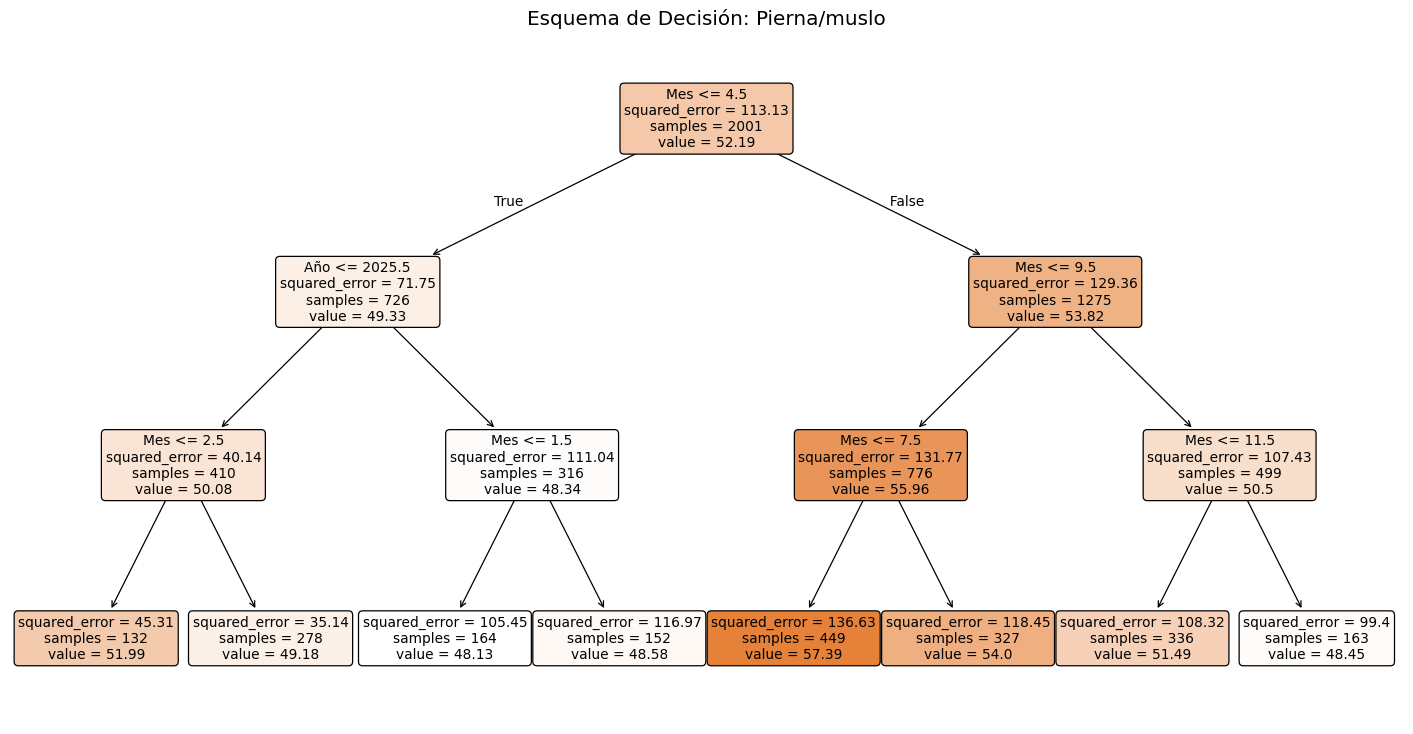


 Predicción para Pierna/muslo en Mayo 2026: $57.39


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from datetime import datetime

%matplotlib inline

# --- CONFIGURACIÓN ---
path = '/content/base de datos.xlsx'
PIEZA_OBJETIVO = 'Pierna/muslo' # Nombre corregido con la diagonal

def cargar_datos_limpios(ruta):
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []
        for nombre, df in dict_hojas.items():
            df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in str(col[1]) else col[0] for col in df.columns]
            df = df.rename(columns={df.columns[0]: 'Fecha'})
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            df = df.dropna(subset=['Fecha'])
            lista_df.append(df)
        return pd.concat(lista_df, ignore_index=True)
    except Exception as e:
        print(f" Error al cargar Excel: {e}")
        return None

def limpiar_dinero(valor):
    if pd.isna(valor) or str(valor).strip() in ['-', 'nan', '']:
        return np.nan
    try:
        return float(str(valor).replace('$', '').replace(',', '').strip())
    except:
        return np.nan

# --- EJECUCIÓN ---
df_base = cargar_datos_limpios(path)

if df_base is not None:
    try:
        # Búsqueda flexible de la columna de frecuencia
        # Esto busca cualquier columna que contenga "Pierna", "muslo" y "Fre"
        col_frec_candidatos = [c for c in df_base.columns if 'Pierna' in c and 'Fre' in c]

        if not col_frec_candidatos:
            print(f" No se encontró la columna para '{PIEZA_OBJETIVO}'.")
            print("Columnas disponibles:", list(df_base.columns))
        else:
            col_frec = col_frec_candidatos[0]
            col_min = col_frec.replace('_Frec', '_Min').replace('_Frecc', '_Min')

            df_p = pd.DataFrame({
                'Fecha': df_base['Fecha'],
                'Frec': df_base[col_frec].apply(limpiar_dinero)
            }).dropna()

            X = pd.DataFrame({
                'Año': df_p['Fecha'].dt.year,
                'Mes': df_p['Fecha'].dt.month
            })

            # Árbol con profundidad 3 para que sea legible pero detallado
            modelo = DecisionTreeRegressor(max_depth=3, random_state=42)
            modelo.fit(X, df_p['Frec'])

            # --- RENDERIZADO DE LA IMAGEN ---
            plt.figure(figsize=(20, 10), dpi=90)

            plot_tree(modelo,
                      feature_names=['Año', 'Mes'],
                      filled=True,
                      rounded=True,
                      fontsize=11,
                      precision=2)

            plt.title(f"Esquema de Decisión: {PIEZA_OBJETIVO}", fontsize=16)
            plt.show()

            # Predicción final
            fecha_proyectada = datetime(2026, 5, 1)
            pred = modelo.predict([[fecha_proyectada.year, fecha_proyectada.month]])[0]
            print(f"\n Predicción para {PIEZA_OBJETIVO} en Mayo 2026: ${pred:,.2f}")

    except Exception as e:
        print(f" Ocurrió un error: {e}")

/tmp/ipykernel_9342/4104921664.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/4104921664.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/4104921664.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/4104921664.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To 

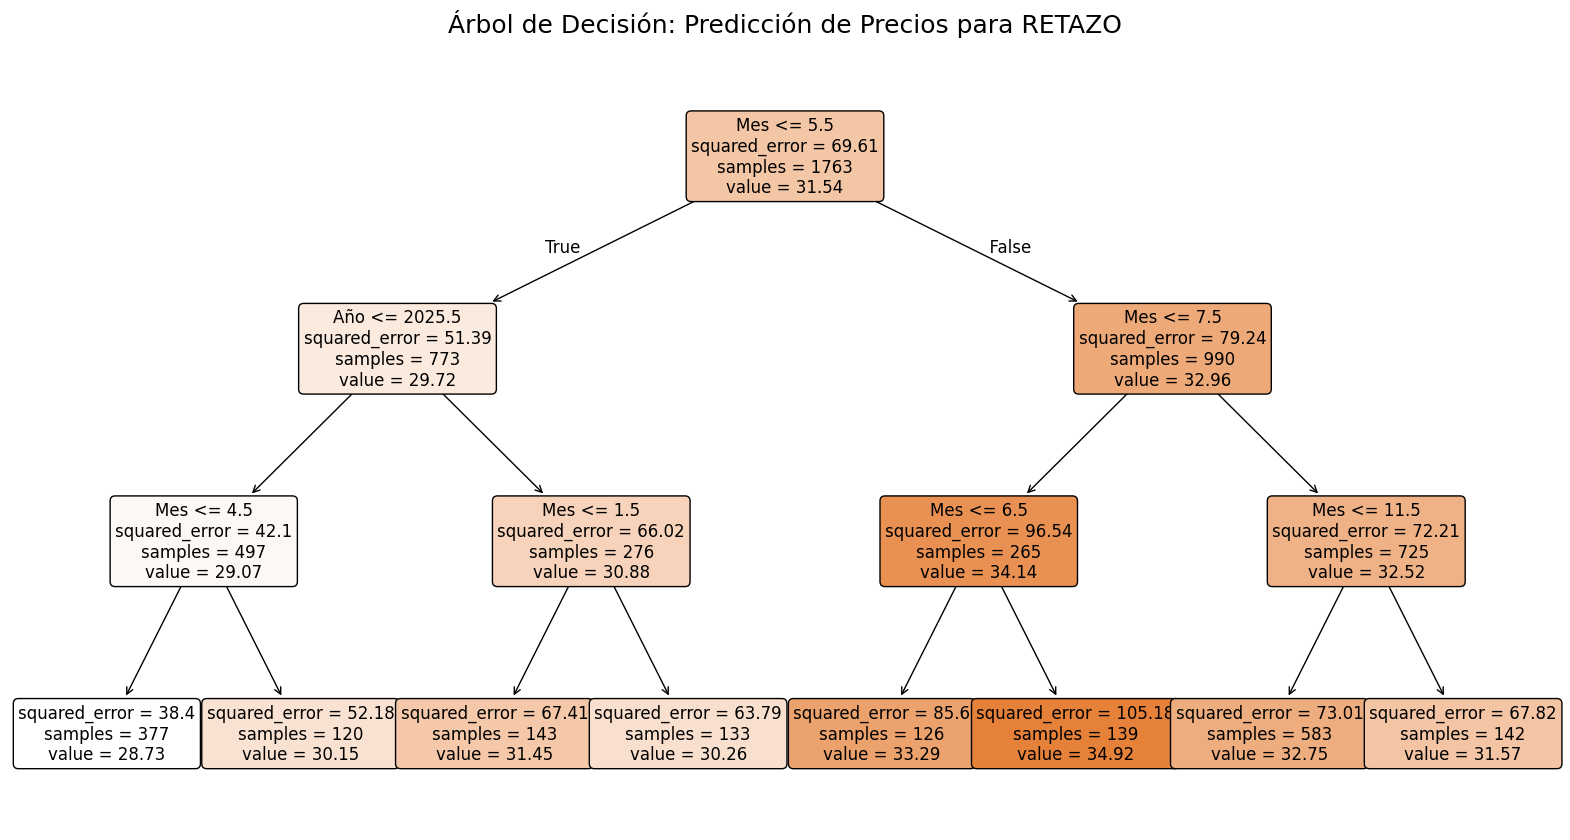


 RESULTADO FINAL PARA RETAZO:
Predicción para Mayo 2026: $30.26


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from datetime import datetime


%matplotlib inline

# --- CONFIGURACIÓN ---
path = '/content/base de datos.xlsx'
PIEZA_OBJETIVO = 'Retazo'

def cargar_datos_limpios(ruta):
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []
        for nombre, df in dict_hojas.items():
            # Limpieza de nombres de columnas (aplanar MultiIndex)
            df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in str(col[1]) else col[0] for col in df.columns]
            df = df.rename(columns={df.columns[0]: 'Fecha'})
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            df = df.dropna(subset=['Fecha'])
            lista_df.append(df)
        return pd.concat(lista_df, ignore_index=True)
    except Exception as e:
        print(f" Error al cargar Excel: {e}")
        return None

def limpiar_dinero(valor):
    if pd.isna(valor) or str(valor).strip() in ['-', 'nan', '']:
        return np.nan
    try:
        return float(str(valor).replace('$', '').replace(',', '').strip())
    except:
        return np.nan

# --- EJECUCIÓN ---
df_base = cargar_datos_limpios(path)

if df_base is not None:
    try:
        # Búsqueda de la columna de frecuencia para 'Retazo'
        col_frec_candidatos = [c for c in df_base.columns if PIEZA_OBJETIVO in c and 'Fre' in c]

        if not col_frec_candidatos:
            print(f" No se encontró la columna para '{PIEZA_OBJETIVO}'.")
            print("Columnas disponibles:", [c for c in df_base.columns if 'Fre' in c])
        else:
            col_frec = col_frec_candidatos[0]

            # Crear DataFrame filtrado
            df_p = pd.DataFrame({
                'Fecha': df_base['Fecha'],
                'Frec': df_base[col_frec].apply(limpiar_dinero)
            }).dropna()

            # Variables de entrada: Año y Mes
            X = pd.DataFrame({
                'Año': df_p['Fecha'].dt.year,
                'Mes': df_p['Fecha'].dt.month
            })

            # Modelo de Árbol (Profundidad 3 para máxima claridad)
            modelo_retazo = DecisionTreeRegressor(max_depth=3, random_state=42)
            modelo_retazo.fit(X, df_p['Frec'])

            # --- RENDERIZADO DEL DIAGRAMA ---
            plt.figure(figsize=(20, 10), dpi=100)

            plot_tree(modelo_retazo,
                      feature_names=['Año', 'Mes'],
                      filled=True,
                      rounded=True,
                      fontsize=12,
                      precision=2,
                      node_ids=False)

            plt.title(f"Árbol de Decisión: Predicción de Precios para {PIEZA_OBJETIVO.upper()}", fontsize=18, pad=20)
            plt.show()

            # Predicción para Mayo 2026
            fecha_proyectada = datetime(2026, 5, 1)
            pred = modelo_retazo.predict([[fecha_proyectada.year, fecha_proyectada.month]])[0]

            print(f"\n RESULTADO FINAL PARA {PIEZA_OBJETIVO.upper()}:")
            print(f"Predicción para Mayo 2026: ${pred:,.2f}")

    except Exception as e:
        print(f" Error en el proceso: {e}")

/tmp/ipykernel_9342/170728776.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/170728776.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/170728776.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9342/170728776.py:21: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensu

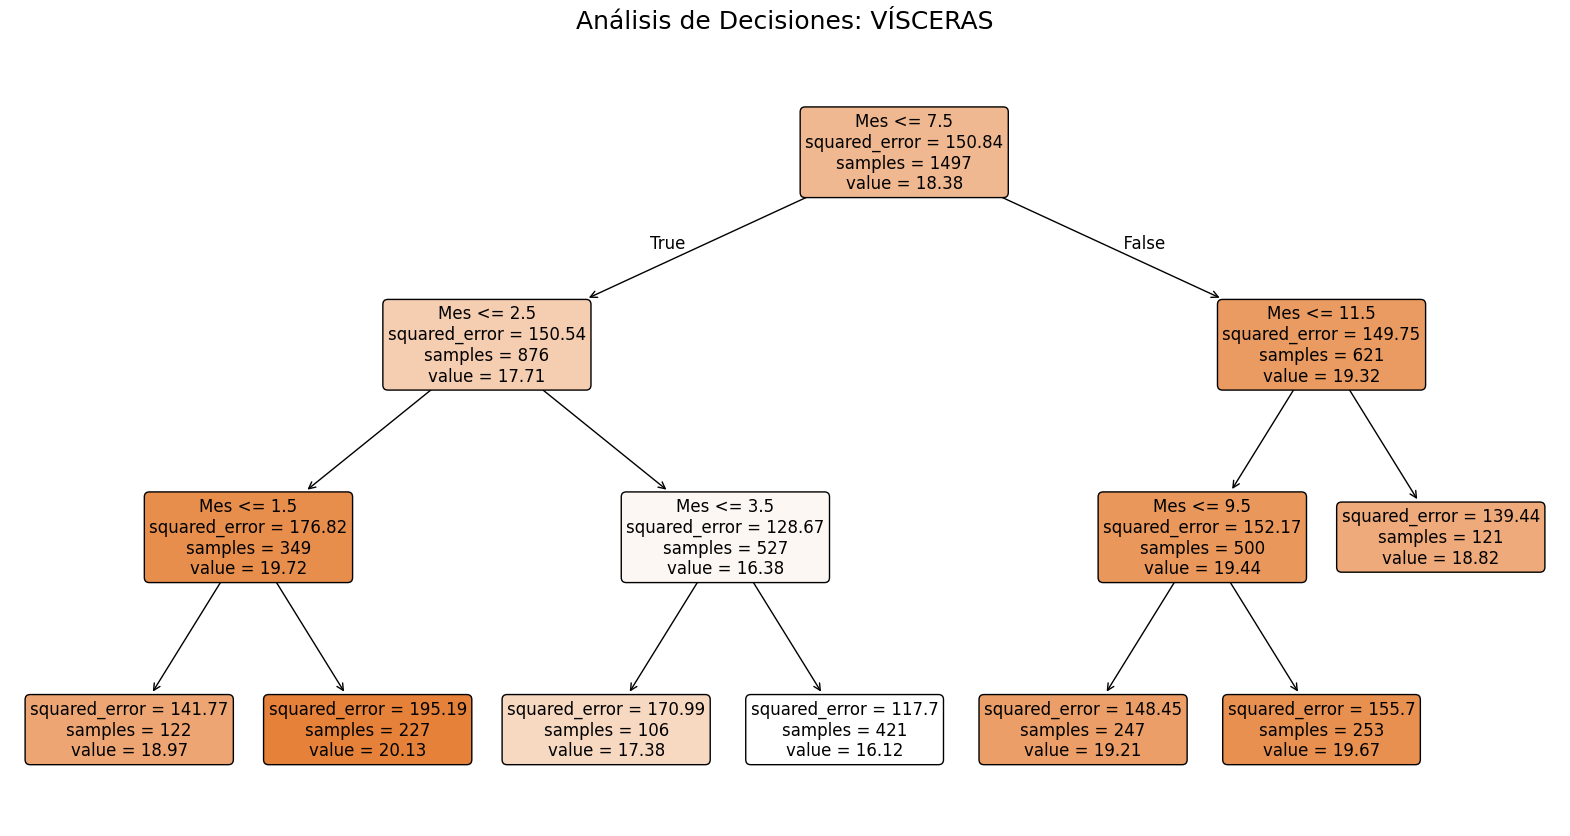


📈 RESULTADO PARA VÍSCERAS:
Predicción estimada para Mayo 2026: $16.12


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from datetime import datetime


%matplotlib inline

# --- CONFIGURACIÓN ---
path = '/content/base de datos.xlsx'

def cargar_datos_limpios(ruta):
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []
        for nombre, df in dict_hojas.items():
            # Aplanamos los encabezados del Excel
            df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in str(col[1]) else col[0] for col in df.columns]
            df = df.rename(columns={df.columns[0]: 'Fecha'})
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            df = df.dropna(subset=['Fecha'])
            lista_df.append(df)
        return pd.concat(lista_df, ignore_index=True)
    except Exception as e:
        print(f" Error al cargar Excel: {e}")
        return None

def limpiar_dinero(valor):
    if pd.isna(valor) or str(valor).strip() in ['-', 'nan', '']:
        return np.nan
    try:
        return float(str(valor).replace('$', '').replace(',', '').strip())
    except:
        return np.nan

# --- EJECUCIÓN PARA VÍSCERAS ---
df_base = cargar_datos_limpios(path)

if df_base is not None:
    try:
        # Búsqueda flexible: intentamos con 'vícera', 'vicera', 'víscera' o 'viscera'
        terminos_busqueda = ['vícera', 'vicera', 'víscera', 'viscera']
        col_frec_candidatos = []

        for termino in terminos_busqueda:
            candidatos = [c for c in df_base.columns if termino in c.lower() and 'Fre' in c]
            col_frec_candidatos.extend(candidatos)

        if not col_frec_candidatos:
            print(f" No se encontró la columna para 'Vísceras'.")
            print("Columnas disponibles:", [c for c in df_base.columns if 'Fre' in c])
        else:
            col_frec = col_frec_candidatos[0]

            df_p = pd.DataFrame({
                'Fecha': df_base['Fecha'],
                'Frec': df_base[col_frec].apply(limpiar_dinero)
            }).dropna()

            X = pd.DataFrame({
                'Año': df_p['Fecha'].dt.year,
                'Mes': df_p['Fecha'].dt.month
            })

            # Modelo con profundidad 3 (Legible y profesional)
            modelo_visceras = DecisionTreeRegressor(max_depth=3, random_state=42)
            modelo_visceras.fit(X, df_p['Frec'])

            # --- DIBUJO DEL ÁRBOL ---
            plt.figure(figsize=(20, 10), dpi=100)

            plot_tree(modelo_visceras,
                      feature_names=['Año', 'Mes'],
                      filled=True,
                      rounded=True,
                      fontsize=12,
                      precision=2)

            plt.title("Análisis de Decisiones: VÍSCERAS", fontsize=18, pad=20)
            plt.show()

            # Predicción Mayo 2026
            fecha_proyectada = datetime(2026, 5, 1)
            pred = modelo_visceras.predict([[fecha_proyectada.year, fecha_proyectada.month]])[0]

            print(f"\n📈 RESULTADO PARA VÍSCERAS:")
            print(f"Predicción estimada para Mayo 2026: ${pred:,.2f}")

    except Exception as e:
        print(f" Error técnico: {e}")

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

# --- CONFIGURACIÓN ---
path = '/content/base de datos.xlsx'

def cargar_y_limpiar_base(ruta):
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []
        for nombre, df in dict_hojas.items():
            df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in str(col[1]) else col[0] for col in df.columns]
            df = df.rename(columns={df.columns[0]: 'Fecha'})
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            df = df.dropna(subset=['Fecha'])
            lista_df.append(df)
        return pd.concat(lista_df, ignore_index=True)
    except Exception as e:
        print(f"Error: {e}")
        return None

def limpiar_dinero(valor):
    if pd.isna(valor) or str(valor).strip() in ['-', 'nan', '']: return np.nan
    try: return float(str(valor).replace('$', '').replace(',', '').strip())
    except: return np.nan

# --- LÓGICA DEL PROBLEMA PROTOTÍPICO ---
def analizar_similitud_productos(df, producto_objetivo):
    print(f"--- ANALIZANDO 'ALMAS GEMELAS' PARA: {producto_objetivo.upper()} ---\n")

    # 1. Obtener la lista de todos los productos disponibles
    piezas = [c.replace('_Min', '') for c in df.columns if '_Min' in c]

    # Creamos un diccionario de comportamientos (tendencias de precio)
    comportamientos = {}

    for pieza in piezas:
        col_min = f"{pieza}_Min"
        # Limpiamos y obtenemos el promedio de precio histórico
        precios = df[col_min].apply(limpiar_dinero).dropna()
        if len(precios) > 0:
            # Definimos el "comportamiento" como si el precio es Alto, Medio o Bajo
            promedio = precios.mean()
            comportamientos[pieza] = {
                'promedio': promedio,
                'max': precios.max(),
                'tendencia': "Alza" if precios.iloc[-1] > precios.iloc[0] else "Baja"
            }

    # 2. Lógica de comparación (Similar a tu código de la cafetería)
    # Buscamos productos que compartan la misma tendencia y rango de precio
    objetivo_data = comportamientos.get(producto_objetivo)

    if not objetivo_data:
        print("Producto objetivo no encontrado.")
        return

    recomendaciones = []

    for otra_pieza, data in comportamientos.items():
        if otra_pieza == producto_objetivo:
            continue

        # Criterio de "Almas Gemelas": Misma tendencia y precios cercanos (margen 20%)
        misma_tendencia = data['tendencia'] == objetivo_data['tendencia']
        precio_similar = abs(data['promedio'] - objetivo_data['promedio']) / objetivo_data['promedio'] < 0.20

        if misma_tendencia and precio_similar:
            print(f"¡{producto_objetivo} y {otra_pieza} son 'Almas Gemelas' de mercado!")
            print(f"   -> Ambos están al {data['tendencia']} y tienen precios similares.")
            recomendaciones.append(otra_pieza)

    # 3. Resultado final
    print(f"\nRecomendación: Si monitoreas {producto_objetivo}, deberías observar también: {recomendaciones}")

# --- EJECUCIÓN ---
df_precios = cargar_y_limpiar_base(path)
if df_precios is not None:
    # Cambia 'Pechuga' por el producto que quieras comparar
    analizar_similitud_productos(df_precios, 'Pechuga')

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime

# --- CONFIGURACIÓN ---
path = '/content/base de datos.xlsx'

def cargar_y_limpiar_base(ruta):
    try:
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        lista_df = []
        for nombre, df in dict_hojas.items():
            df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in str(col[1]) else col[0] for col in df.columns]
            df = df.rename(columns={df.columns[0]: 'Fecha'})
            df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
            df = df.dropna(subset=['Fecha'])
            lista_df.append(df)
        return pd.concat(lista_df, ignore_index=True)
    except Exception as e:
        print(f"Error: {e}")
        return None

def limpiar_dinero(valor):
    if pd.isna(valor) or str(valor).strip() in ['-', 'nan', '']: return np.nan
    try: return float(str(valor).replace('$', '').replace(',', '').strip())
    except: return np.nan

# --- LÓGICA DEL PROBLEMA PROTOTÍPICO ---
def analizar_similitud_productos(df, producto_objetivo):
    print(f"--- ANALIZANDO 'ALMAS GEMELAS' PARA: {producto_objetivo.upper()} ---\n")

    # 1. Obtener la lista de todos los productos disponibles
    piezas = [c.replace('_Min', '') for c in df.columns if '_Min' in c]

    # Creamos un diccionario de comportamientos (tendencias de precio)
    comportamientos = {}

    for pieza in piezas:
        col_min = f"{pieza}_Min"
        # Limpiamos y obtenemos el promedio de precio histórico
        precios = df[col_min].apply(limpiar_dinero).dropna()
        if len(precios) > 0:
            # Definimos el "comportamiento" como si el precio es Alto, Medio o Bajo
            promedio = precios.mean()
            comportamientos[pieza] = {
                'promedio': promedio,
                'max': precios.max(),
                'tendencia': "Alza" if precios.iloc[-1] > precios.iloc[0] else "Baja"
            }

    # 2. Lógica de comparación (Similar a tu código de la cafetería)
    # Buscamos productos que compartan la misma tendencia y rango de precio
    objetivo_data = comportamientos.get(producto_objetivo)

    if not objetivo_data:
        print("Producto objetivo no encontrado.")
        return

    recomendaciones = []

    for otra_pieza, data in comportamientos.items():
        if otra_pieza == producto_objetivo:
            continue

        # Criterio de "Almas Gemelas": Misma tendencia y precios cercanos (margen 20%)
        misma_tendencia = data['tendencia'] == objetivo_data['tendencia']
        precio_similar = abs(data['promedio'] - objetivo_data['promedio']) / objetivo_data['promedio'] < 0.20

        if misma_tendencia and precio_similar:
            print(f"¡{producto_objetivo} y {otra_pieza} son 'Almas Gemelas' de mercado!")
            print(f"   -> Ambos están al {data['tendencia']} y tienen precios similares.")
            recomendaciones.append(otra_pieza)

    # 3. Resultado final
    print(f"\nRecomendación: Si monitoreas {producto_objetivo}, deberías observar también: {recomendaciones}")

# --- EJECUCIÓN ---
df_precios = cargar_y_limpiar_base(path)
if df_precios is not None:
    # Cambia 'Pechuga' por el producto que quieras comparar
    analizar_similitud_productos(df_precios, 'Pechuga')

/tmp/ipykernel_9811/429958299.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9811/429958299.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9811/429958299.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
/tmp/ipykernel_9811/429958299.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensu

--- ANALIZANDO 'ALMAS GEMELAS' PARA: PECHUGA ---


Recomendación: Si monitoreas Pechuga, deberías observar también: []


In [ ]:
import pandas as pd

def analizar_alerta_precios(historial_precios, margen_alerta, tiempo_minimo_estabilidad):
    """
    Analiza si el precio está cerca de un valor crítico (Geofencing)
    y si se ha mantenido estable ahí (Stay Point).
    """

    PRECIO_CRITICO = 100
    RADIO_ALERTA = margen_alerta # Qué tan cerca del límite queremos la notificación

    print(f"{'FECHA':<12} | {'PRECIO':<10} | {'ESTADO':<15} | {'ACCIÓN COMERCIAL'}")
    print("-" * 75)

    for i in range(len(historial_precios)):
        p = historial_precios[i]

        # 1. Distancia al Precio Crítico (Distancia Euclidiana en 1D)
        distancia_al_limite = abs(PRECIO_CRITICO - p['precio'])

        # 2. Lógica de Geofencing de Mercado (Notificación)
        notificacion = "MERCADO ESTABLE"
        if distancia_al_limite <= RADIO_ALERTA:
            notificacion = "⚠️ ¡ALERTA DE PRECIO!"

        # 3. Lógica de Estabilidad (Stay Point de Precio)
        if i < len(historial_precios) - 1:
            # Calculamos cuánto tiempo duró ese precio hasta el siguiente registro
            duracion = historial_precios[i+1]['dia'] - p['dia']
            estado = "ESTABLE" if duracion >= tiempo_minimo_estabilidad else "VOLÁTIL"
        else:
            estado = "FIN REPORTE"

        print(f"{p['fecha']:<12} | ${p['precio']:>8.2f} | {estado:<15} | {notificacion}")

# --- DATOS DE PRUEBA (Precios de Pechuga/Retazo) ---
datos_mercado = [
    {'fecha':'2026-04-01', 'precio':115.0, 'dia':1},  # Lejos del límite - Volátil
    {'fecha':'2026-04-02', 'precio':101.5, 'dia':2},  # CERCA (Alerta) - Estable (duró 5 días)
    {'fecha':'2026-04-07', 'precio':101.5, 'dia':7},  # CERCA (Alerta) - Volátil
    {'fecha':'2026-04-08', 'precio':120.0, 'dia':8},  # Lejos - Fin
]

# Ejecutar: Alerta si el precio está a menos de $5 del crítico y dura 3 días estable
analizar_alerta_precios(datos_mercado, margen_alerta=5, tiempo_minimo_estabilidad=3)

FECHA        | PRECIO     | ESTADO          | ACCIÓN COMERCIAL
---------------------------------------------------------------------------
2026-04-01   | $  115.00 | VOLÁTIL         | MERCADO ESTABLE
2026-04-02   | $  101.50 | ESTABLE         | ⚠️ ¡ALERTA DE PRECIO!
2026-04-07   | $  101.50 | VOLÁTIL         | ⚠️ ¡ALERTA DE PRECIO!
2026-04-08   | $  120.00 | FIN REPORTE     | MERCADO ESTABLE


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

# --- CONFIGURACIÓN DE MINERÍA ---
PATH = '/content/base de datos.xlsx'
PRODUCTO = 'Pechuga'

def mineria_datos_prototipo(ruta):
    try:
        # 1. EXTRACCIÓN (ETL)
        dict_hojas = pd.read_excel(ruta, sheet_name=None, header=[1, 2])
        df = pd.concat([h for h in dict_hojas.values()], ignore_index=True)
        df.columns = [f"{col[0]}_{col[1]}" if 'Unnamed' not in str(col[1]) else col[0] for col in df.columns]
        df = df.rename(columns={df.columns[0]: 'Fecha'})
        df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')

        # 2. TRANSFORMACIÓN (Limpieza profunda para Minería)
        col_frec = [c for c in df.columns if PRODUCTO in c and 'Fre' in c][0]

        def limpiar_precios(x):
            if pd.isna(x): return np.nan
            s = str(x).replace('$', '').replace(',', '').strip()
            try: return float(s)
            except: return np.nan

        df_mineria = pd.DataFrame({
            'Fecha': df['Fecha'],
            'Precio': df[col_frec].apply(limpiar_precios),
            'Mes': df['Fecha'].dt.month,
            'Anio': df['Fecha'].dt.year
        }).dropna().sort_values('Fecha')

        # 3. DISCRETIZACIÓN (Creación de etiquetas para Clasificación)
        # Dividimos los precios en 3 categorías: Bajo, Medio, Alto
        df_mineria['Categoria_Precio'] = pd.qcut(df_mineria['Precio'], q=3, labels=['Bajo', 'Medio', 'Alto'])

        # 4. MODELADO: Árbol de Clasificación (Minería Predictiva)
        X = df_mineria[['Anio', 'Mes']]
        y = df_mineria['Categoria_Precio']

        # Entrenamos el clasificador
        clf = DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=42)
        clf.fit(X, y)

        # --- VISUALIZACIÓN DE RESULTADOS ---
        print(f"--- REPORTE DE MINERÍA DE DATOS: {PRODUCTO.upper()} ---")
        print(f"Total de registros minados: {len(df_mineria)}")
        print("\nDistribución de Clases de Precio:")
        print(df_mineria['Categoria_Precio'].value_counts())

        # Dibujar el árbol de clasificación
        plt.figure(figsize=(20, 10))
        plot_tree(clf,
                  feature_names=['Año', 'Mes'],
                  class_names=['Bajo', 'Medio', 'Alto'],
                  filled=True,
                  rounded=True,
                  fontsize=12)
        plt.title(f"Minería de Datos: Reglas de Clasificación para {PRODUCTO}")
        plt.show()

        # 5. PREDICCIÓN DE CLASE PARA MAYO 2026
        pred_clase = clf.predict([[2026, 5]])[0]
        print(f"\n💎 INSIGHT DE MINERÍA: Para Mayo 2026, se espera un nivel de precio: **{pred_clase.upper()}**")

    except Exception as e:
        print(f"❌ Error en el proceso de minería: {e}")

# Ejecutar el proceso
mineria_datos_prototipo(PATH)

❌ Error en el proceso de minería: Bin edges must be unique: Index([nan, nan, nan, nan], dtype='float64', name='Precio').
You can drop duplicate edges by setting the 'duplicates' kwarg


/tmp/ipykernel_9811/373591730.py:19: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Fecha'] = pd.to_datetime(df['Fecha'], errors='coerce')
